In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv(r'C:\FBS\Data Analysis\classification\Iris.csv')

In [3]:
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
df.columns=['SepalLength','Spealwidth','PetalLength','Petalwidth','Species']

In [5]:
import seaborn as sns

<Axes: xlabel='SepalLength', ylabel='PetalLength'>

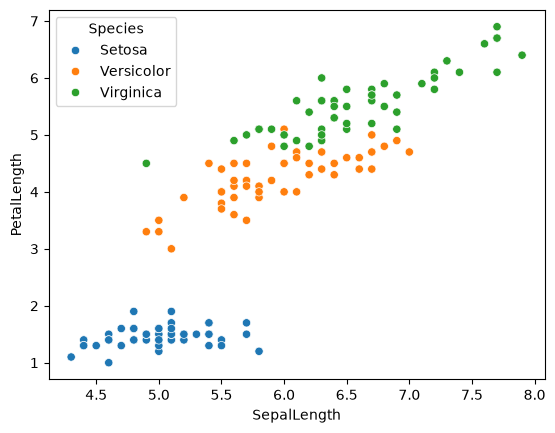

In [6]:
sns.scatterplot(x='SepalLength',y='PetalLength',hue='Species',data=df)

In [9]:
df['s_ns']=np.where(df['Species']=='Setosa',1,0)
df['s_ns'].value_counts()



s_ns
0    100
1     50
Name: count, dtype: int64

<Axes: xlabel='SepalLength', ylabel='PetalLength'>

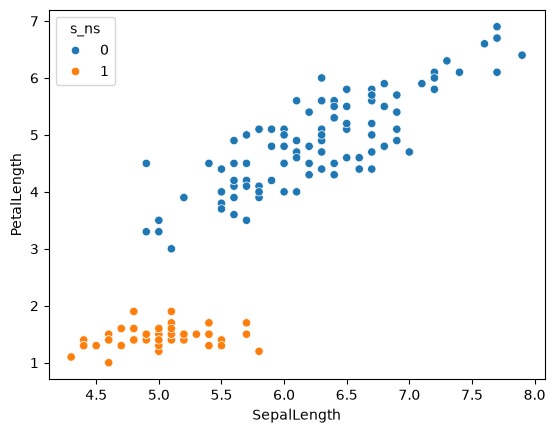

In [10]:
sns.scatterplot(x='SepalLength',y='PetalLength',hue='s_ns',data=df)

In [12]:
x=df[['PetalLength','Petalwidth']]
y=df['s_ns']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [13]:
from sklearn.svm import SVC
linear_svm=SVC()

In [14]:
linear_svm.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
linear_svm.score(x_train,y_train)

1.0

In [22]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from mlxtend.plotting import plot_decision_regions

In [25]:
type(y)

pandas.Series

C:\Users\pg236\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: >

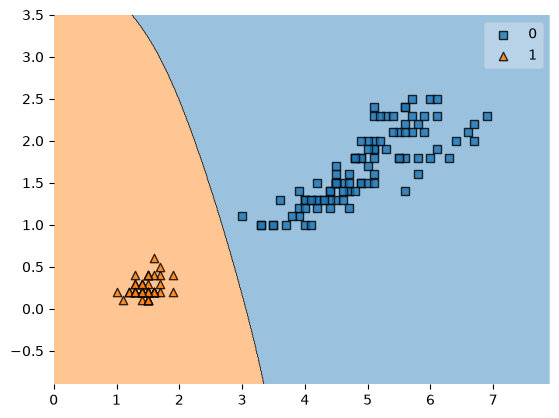

In [26]:

plot_decision_regions(
    x.values,
    y.values,
    clf=linear_svm
)

In [27]:
from sklearn.preprocessing import LabelEncoder


In [28]:
lbl=LabelEncoder()

In [31]:
df_species=lbl.fit_transform(df['Species'])
df['Species_encoded']=df_species

In [32]:
x=df[['PetalLength','Petalwidth']]
y=df['Species_encoded']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [33]:
linear_svm=SVC(kernel='linear')
linear_svm.fit(x_train,y_train)
linear_svm.score(x_train,y_train)

0.9666666666666667

C:\Users\pg236\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: >

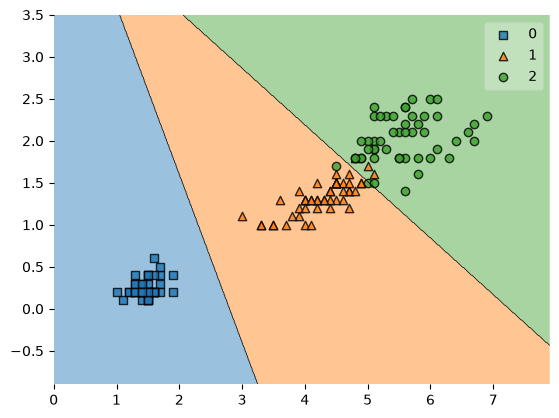

In [35]:
plot_decision_regions(
    x.values,
    y.values,
    clf=linear_svm
)

In [36]:
poly_svm=SVC(kernel='poly')
poly_svm.fit(x_train,y_train)
poly_svm.score(x_train,y_train)

0.9666666666666667

C:\Users\pg236\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: >

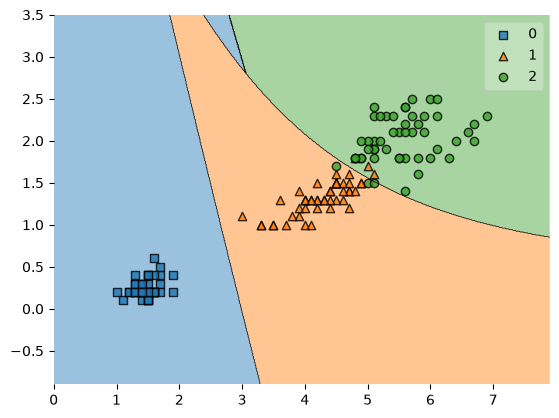

In [38]:
plot_decision_regions(
    x.values,
    y.values,
    clf=poly_svm
)

In [39]:
radial_svm=SVC(kernel='rbf')
radial_svm.fit(x_train,y_train)
radial_svm.score(x_train,y_train)

0.9666666666666667

C:\Users\pg236\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: >

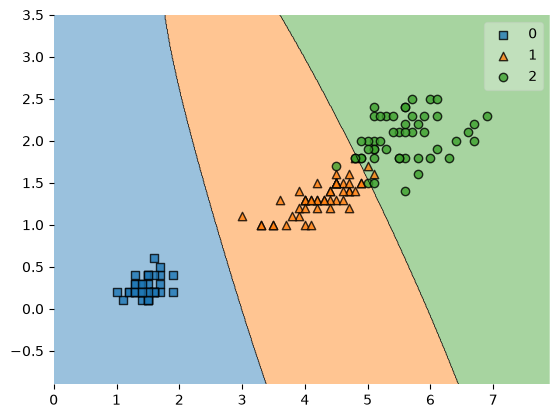

In [40]:
plot_decision_regions(
    x.values,
    y.values,
    clf=radial_svm
)